In [2]:
# ============================================================
# MODELAGEM PREDITIVA - BANK CUSTOMER CHURN
# ============================================================

# --- Bibliotecas ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve
)



In [5]:
url = 'https://raw.githubusercontent.com/itgirlhightech/Ada-Churn-Project/refs/heads/main/src/Churn_Modelling.csv?token=GHSAT0AAAAAAD4KGRF3ISUMHBHNNW7PV4VI2P53Q7A'
df = pd.read_csv(url)
print("Shape:", df.shape)
display(df.head())

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
# --- Removendo colunas sem valor preditivo ---
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# --- Encoding das variáveis categóricas ---
# Geography e Gender são texto, precisam virar números
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

# --- Separando features (X) e target (y) ---
X = df.drop(columns=['Exited'])
y = df['Exited']

print("Features utilizadas:")
print(X.columns.tolist())
print(f"\nDistribuição do target:\n{y.value_counts()}")

##removemos colunas que são só identificadores (nome, ID) e convertemos texto em números com get_dummies. O drop_first=True evita redundância — se Geography vira Germany e Spain, o France já é implícito quando ambos são 0.##

KeyError: "['RowNumber', 'CustomerId', 'Surname'] not found in axis"

--- Pré-processamento
removemos colunas que são só identificadores (nome, ID) e convertemos texto em números com get_dummies. O drop_first=True evita redundância — se Geography vira Germany e Spain, o France já é implícito quando ambos são 0.

In [8]:
# --- Train/Test Split e Normalização ---
# --- Dividindo em treino (80%) e teste (20%) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Normalizando as variáveis numéricas ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Treino: {X_train.shape[0]} linhas")
print(f"Teste:  {X_test.shape[0]} linhas")

Treino: 8000 linhas
Teste:  2000 linhas


A Regressão Logística é sensível à escala das variáveis. Sem isso, uma variável como Balance (valores na casa dos milhares) dominaria sobre NumOfProducts (valores de 1 a 4). O StandardScaler coloca tudo na mesma escala.
stratify=y garante que a proporção de churn (80/20) seja mantida tanto no treino quanto no teste.

In [9]:
# --- Treinamento dos Modelos ---
# --- Regressão Logística ---
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Modelos treinados com sucesso!")

Modelos treinados com sucesso!


In [10]:
# --- Avaliação com Métricas ---
# --- Função para calcular e exibir todas as métricas ---
def avaliar_modelo(nome, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    print(f"\n{'='*45}")
    print(f"  {nome}")
    print(f"{'='*45}")
    print(f"  Acurácia:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")
    print(f"  ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")

avaliar_modelo("Regressão Logística", lr, X_test, y_test)
avaliar_modelo("Random Forest",       rf, X_test, y_test)


  Regressão Logística
  Acurácia:  0.8080
  Precision: 0.5891
  Recall:    0.1867
  F1-Score:  0.2836
  ROC-AUC:   0.7748

  Random Forest
  Acurácia:  0.8640
  Precision: 0.7824
  Recall:    0.4595
  F1-Score:  0.5789
  ROC-AUC:   0.8522


RECALL
No contexto de churn, é mais custoso não identificar um cliente que vai sair do que acionar um que ficaria. Um cliente perdido representa receita perdida; uma ação de retenção desnecessária custa muito menos

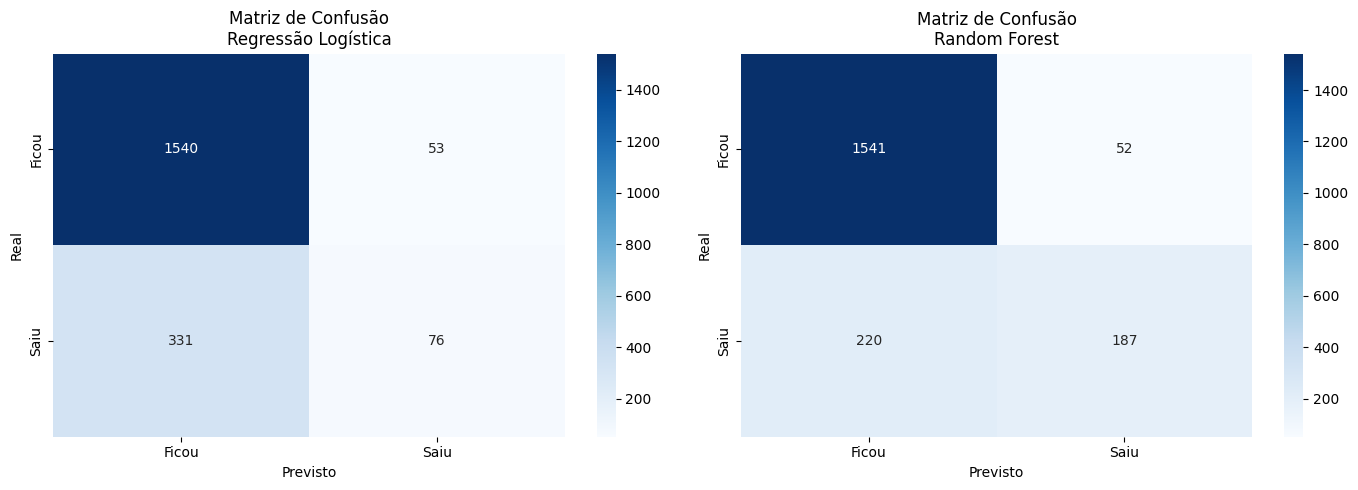

In [11]:
# --- Matriz de Confusão ---
#----Cross-Validation----#
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelos = [("Regressão Logística", lr), ("Random Forest", rf)]

for ax, (nome, modelo) in zip(axes, modelos):
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ficou', 'Saiu'],
                yticklabels=['Ficou', 'Saiu'])
    ax.set_title(f'Matriz de Confusão\n{nome}')
    ax.set_xlabel('Previsto')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

Quanto mais a curva se afasta da linha diagonal pontilhada (aleatório) e se aproxima do canto superior esquerdo, melhor o modelo. O AUC é a área embaixo dessa curva — quanto maior, mais o modelo consegue separar clientes que vão sair dos que vão ficar, independente do threshold escolhido.

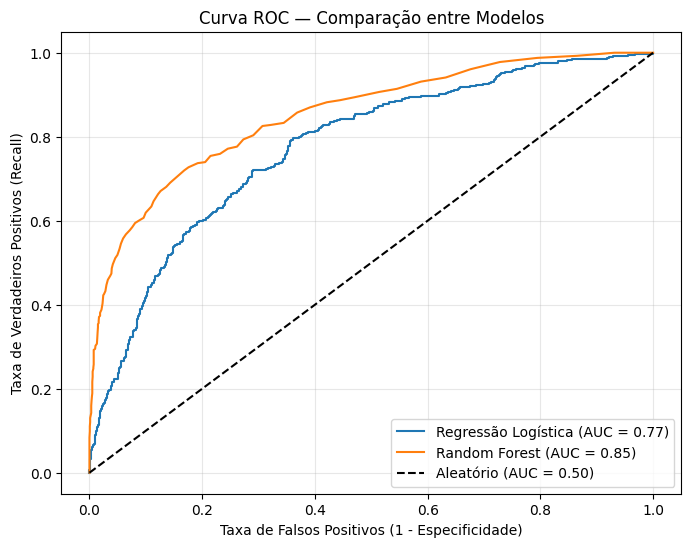

In [12]:
# --- Curva ROC e AUC ---
plt.figure(figsize=(8, 6))

for nome, modelo in modelos:
    y_proba = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{nome} (AUC = {auc:.2f})")

# Linha de referência: modelo aleatório
plt.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.50)')

plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)')
plt.title('Curva ROC — Comparação entre Modelos')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Explicação ROC e AUC
As linhas são o que realmente aconteceu, as colunas são o que o modelo previu. Os números na diagonal principal são os acertos.
Os erros fora da diagonal são os Falsos Positivos (previu churn, cliente ficou) e Falsos Negativos (não previu churn, cliente saiu) — esse segundo é o mais preocupante.

/tmp/ipykernel_21747/3303782188.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


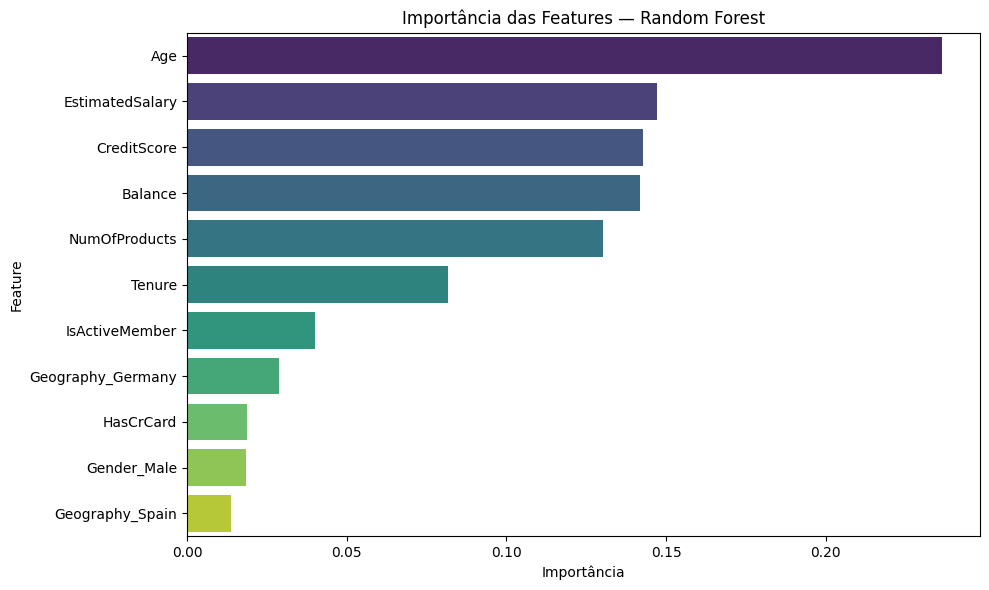

In [13]:
#---Importância das features: Random Forest---#

feature_names = X.columns.tolist()
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(
    x=importances[indices],
    y=[feature_names[i] for i in indices],
    palette='viridis'
)
plt.title('Importância das Features — Random Forest')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Aqui são quais variáveis o modelo considerou mais decisivas para prever o churn. Como Age e IsActiveMember aparecerem no topo, isso confirma os achados da EDA e dá recomendações concretas para a área de retenção.

CONCLUSÕES E RECOMENDAÇÕES

Com base em Age

Criar um programa de fidelidade específico para clientes acima de 45 anos — faixa com maior churn na EDA (36–46%)
Oferecer produtos adequados a esse perfil: previdência privada, investimentos de longo prazo, atendimento preferencial
Acionar o time de retenção proativamente quando um cliente dessa faixa reduzir movimentações


Com base em IsActiveMember

Clientes inativos têm quase o dobro de churn — implementar um fluxo de reengajamento automático: e-mail, notificação, ligação após X dias sem uso
Definir uma régua de comunicação: cliente sem login há 30 dias → alerta interno; 60 dias → contato ativo do gerente
Criar incentivos para uso: cashback, isenção de tarifas, acesso a produtos exclusivos para quem mantém atividade


Portanto o cliente de maior risco é: acima de 45 anos + inativo + com saldo positivo (a EDA mostrou que saldo zero tem menos churn)
Esse perfil deve ser prioridade máxima para o time de retenção — vale criar um score de risco combinando essas variáveis para monitoramento contínuo